# Introduction to 3D Volumetric Images

__Author(s):__ Masa Prodanovic

__Last Update:__ Jan. 2026

Copyright © 2026 Digital Porous Media Team. All rights reserved.

---

In this lecture we will work with visual inspection of a volumetric data (3D stack). Unlike 2D images that have widely adopted, if different, image formats (jpeg, png, tiff...), the same is not true for 3D data. 

In addition to well-documented formats (tiff, netcdf, or simply a stack of indexed 2D images stored as tifs or jpegs), it is very common to store them as binary arrays, in which case someone has to tell you what the image dimensions, data type and endian-ness is (or email you or save somewhere or...you see how that information can be easily lost). 

Sometimes images are even saved as text (ASCII, human-readable rather than binary) data, which has limitations on number types, accuracy and size.

Additional resources: 
- Check out associated introduction slides
- http://scipy-lectures.org/packages/3d_plotting/index.html

## Imports
For better clarity, let's import all required modules here at the beginning.

In [ ]:
import requests # library for file download - not needed any more

import numpy as np
import matplotlib.pyplot as plt
import skimage
from skimage import io

import dpm_tools
from dpm_tools.io import download_file
from dpm_tools.metrics import histogram_statistics as hist_stats


from pathlib import Path
import os
import sys
sys.path.append("..")
from utils.dataloader import load_sample
download_path = Path("/home/jovyan/work/ls6/dpm_teach_cache")

## Basic review of 3D data ordering in NumPy array

In [2]:
# create a simple 3D array of all zeros and print it, 
# so we see how NumPy visualizes positions.
slices = 2
height = 3
width  = 4
A = np.zeros([slices,height,width])

print('original\n',A)

# Now we will modify certain positions to understand where 
# specific locations are

A[1,:,:]=1
print('change\n',A)


A[0,2,:] = 6
print('change\n',A)

A.shape = (1,24)
print('This shows how 3D array would be fit into a continous section', 
      'of memory when written as a binary file\n',A)

original
 [[[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]]
change
 [[[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]]
change
 [[[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [6. 6. 6. 6.]]

 [[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]]
This shows how 3D array would be fit into a continous section of memory when written as a binary file
 [[0. 0. 0. 0. 0. 0. 0. 0. 6. 6. 6. 6. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


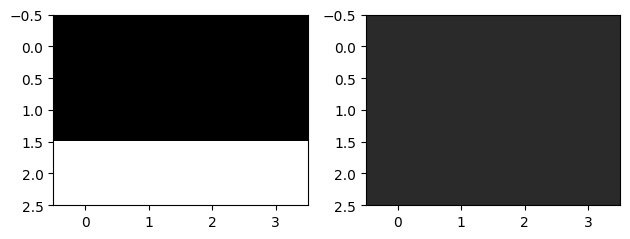

In [3]:
# reshape to the original shape
A.shape = (2,3,4)

fig, axes = plt.subplots(1, 2, tight_layout=True);

axes[0].imshow(A[0,:,:], cmap='gray',vmin=0,vmax=6);
axes[1].imshow(A[1,:,:], cmap='gray',vmin=0,vmax=6);
print(A[1,:,:])



## Example: proxy vuggy carbonate CT scan
Khan, Hasan J, Prodanovic, Masa, DiCarlo, David. ["Particulate straining in series and parallel vuggy configurations." Digital Porous Media Portal]( https://www.doi.org/10.17612/RJ9P-9438)

Direct download of these images is available from this webpage: ["Web link for Digital Porous Media data"](https://web.corral.tacc.utexas.edu/digitalporousmedia/)

Numpy data types -- select the data type that matches your data!

- ```np.byte``` -- signed 8-bit integer
- ```np.ubyte``` -- unsigned 8-bit integer
- ```np.int16``` -- signed 16-bit integer
- ```np.unit16``` -- unsigned 16-bit integer 
- ```np.single``` -- single precision floating point
- ```np.double``` -- double precision floating point

Refer to the following for a complete list
https://numpy.org/doc/stable/user/basics.types.html

Byte ordering convention also matters (big vs little endian)

```np.dtype.byteorder```

https://numpy.org/doc/stable/user/byteswapping.html

In [4]:
#Read the image from Digital Rocks Portal

width  = 234
height = 234
slices = 19

# read date from file
alldata = load_sample("synthetic_vugs", cache_dir=download_path)

alldata.dtype.byteorder

'|'

## Layout for 3D data

- Computer memory is one-dimensional

- Order for data layout must match the convention from the original input file

We will plot the 5th slice (cross-section) below.
Note that there is a vug (large opening) embeded in the matrix of sintered glass beads.

In [5]:
alldata.shape = (slices,height,width)

__Mixing up dimensions results in reading in junk data.
Let's test this.__

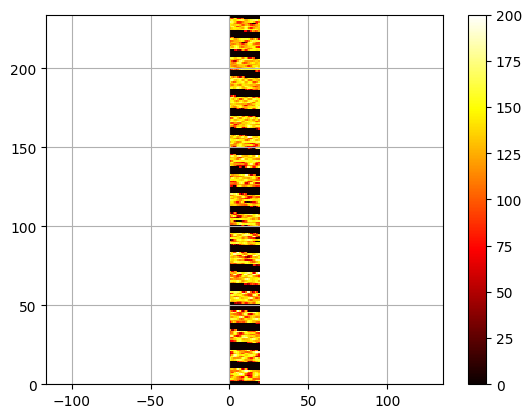

In [6]:
# Test what happens when you mix up dimensions
alldata.shape = (height,width,slices)

image=alldata[5,:,:]
plt.figure(1)
plt.pcolormesh(image,cmap='hot')
plt.grid(True)
plt.axis('equal')
plt.colorbar()
plt.show()